Load libraries

In [1]:
from bertopic import BERTopic
from bertopic.backend import BaseEmbedder
import pandas as pd
import re
import os
from sentence_transformers import SentenceTransformer
from umap import UMAP
import hdbscan
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, PartOfSpeech
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import optuna
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from adapters import AutoAdapterModel
import torch
from pathlib import Path
from tqdm.notebook import tqdm
import itertools
import spacy
from spacy.lang.de import German
from spacy.lang.fr import French
from spacy.lang.es import Spanish
from spacy.lang.it import Italian
from spacy.lang.en import English
from spacy.lang.en import STOP_WORDS as SW_EN
from spacy.lang.de import STOP_WORDS as SW_DE
from spacy.lang.fr import STOP_WORDS as SW_FR
from spacy.lang.es import STOP_WORDS as SW_ES
from spacy.lang.it import STOP_WORDS as SW_IT
import openpyxl

optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import data from other Mediacloud folder

In [2]:
# Load data
OUTPUT_PATH = Path(r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling")
CSV_PATH  = Path(r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\Mediacloud_download+basic_graphs")
ENCODING = "cp1252"

# Read the parquet file
stories = pd.read_parquet(CSV_PATH/"texts_cache.parquet")
# Read the CSV
meta = pd.read_csv(CSV_PATH/"sampled_subtype_stories.csv")
df = stories.merge(meta, on="story_id", how="left")
print(df.head())

                                            story_id  \
0  10ef4a869bc394e1d1400dada9894fb6b57a0990f7ee4b...   
1  73881a452b63b3734322c6ffd410cf1d0f77c541e0ab3c...   
2  d31034cc1afbcae8f822206faec90244d7a628974f5108...   
3  52ade383d67529c0abf9c4fde67808a7bd718f8116540b...   
4  4aab68a71322d8dde5b9d5ab7bfa8d3bc1315410dbae73...   

                                                text  country subtype  \
0                                                NaN  Austria   Aedes   
1                                                NaN  Austria   Aedes   
2  Drostens Warnung hat natürlich wieder zu Zweif...  Austria   Aedes   
3  Die ursprünglich aus den Tropen stammende Asia...  Austria   Aedes   
4  Die durch Hitze bedingte Mortalität könnte sic...  Austria   Aedes   

                                                 url  \
0  http://kurier.at/wissen/update-was-forscher-ue...   
1  http://www.vol.at/nachweis-erbracht-zika-virus...   
2                       https://www.krone.at/3002875   


In [10]:
total = len(df)
success = df["text"].notna().sum()
failed = total - success

print(f"Total:   {total}")
print(f"Success: {success} ({success/total:.1%})")
print(f"Failed:  {failed} ({failed/total:.1%})")

# Break down by country and subtype
print("\nBy country:")
print(df.groupby("country")["text"].apply(lambda x: x.notna().mean()).round(3))

print("\nBy subtype:")
print(df.groupby("subtype")["text"].apply(lambda x: x.notna().mean()).round(3))

# Which domains fail most?
print("\nWorst domains (min 5 attempts):")
domain_stats = df.groupby("media_name")["text"].agg(
    attempts="count",
    success_rate=lambda x: x.notna().mean()
).query("attempts >= 5").sort_values("success_rate").head(15)
print(domain_stats)

Total:   30597
Success: 21044 (68.8%)
Failed:  9553 (31.2%)

By country:
country
Austria        0.737
France         0.644
Germany        0.540
Italy          0.598
Spain          0.886
Switzerland    0.763
Name: text, dtype: float64

By subtype:
subtype
Aedes          0.710
Chikungunya    0.679
Culex          0.705
Dengue         0.692
Usutu          0.569
West Nile      0.733
Zika           0.636
anchor         0.713
Name: text, dtype: float64

Worst domains (min 5 attempts):
                         attempts  success_rate
media_name                                     
lematin.ch                      9      0.047120
suedostschweiz.ch               6      0.066667
lasicilia.it                    5      0.066667
volksfreund.de                  5      0.078125
wormser-zeitung.de              7      0.094595
echo-online.de                  8      0.095238
wiesbadener-kurier.de           7      0.100000
buerstaedter-zeitung.de         6      0.105263
ksta.de                         6    

In [11]:
# Check if German failures are concentrated in a few domains
de_failed = df[(df["country"] == "Germany") & df["text"].isna()]
print(de_failed["media_name"].value_counts().head(15))

media_name
stern.de                     90
hna.de                       84
lvz.de                       84
aachener-nachrichten.de      81
echo-online.de               76
waz-online.de                74
neuepresse.de                68
wormser-zeitung.de           67
tz.de                        66
wiesbadener-kurier.de        63
braunschweiger-zeitung.de    62
volksfreund.de               59
kreiszeitung.de              58
kn-online.de                 57
nordbayern.de                54
Name: count, dtype: int64


Remove NAs and blanks from abstract column

In [12]:
# load dataset
print(f"Loaded {len(df)} rows")
print(df.columns.tolist())
TEXT_COL = "text"

# drop NAs and empty rows
df = df.dropna(subset=[TEXT_COL])
df = df[df[TEXT_COL].str.strip() != ""]
print(f"Rows with text: {len(df)}")

# clean up abstracts by removing abstract headings and links
# clean up multilingual news articles (DE, FR, ES, IT)
def clean_text(text: str) -> str:
    # remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)
    # remove email addresses
    text = re.sub(r"\S+@\S+", "", text)
    # remove social media handles
    text = re.sub(r"@\w+", "", text)
    # remove photo/image/video captions in DE, FR, ES, IT
    text = re.sub(
        r"^(foto|fotos|bild|bilder|photo|photos|image|images|video|videos|"
        r"credit|quelle|source|fuente|fonte|légende|bildunterschrift)[:\s].+$",
        "", text, flags=re.I | re.M
    )
    # remove common news wire tags (e.g. "(dpa)", "(afp)", "(apa)", "(ansa)", "(efe)")
    text = re.sub(r"\((?:dpa|afp|apa|ansa|efe|reuters|sid)\)", "", text, flags=re.I)
    # remove datelines (e.g. "BERLIN (dpa) -", "PARIS, 12. Juni -")
    text = re.sub(r"^[A-ZÄÖÜ\s]+,?\s*[\d\.]*\s*[-–]\s*", "", text, flags=re.M)
    # normalize unicode punctuation (common in FR/ES/IT press)
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = text.replace("\u00ab", '"').replace("\u00bb", '"')  # « »
    # remove repeated whitespace/newlines
    text = re.sub(r"\n{2,}", "\n", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()

df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

BOILERPLATE_PATTERNS = [
    # cookie/tracking consent
    r"cookie[s]?[\s\-]?einstellungen",
    r"datenschutz(erklärung)?",
    r"privacy policy",
    r"politique de confidentialit[eé]",
    r"política de privacidad",
    # paywalls / subscription prompts
    r"angemeldet bleiben",
    r"(bitte\s+)?abonnieren",
    r"s['\u2019]abonner",
    r"susc[rí]bete",
    r"abbonati",
    # adblock notices
    r"adblocker?",
    r"werbeblocker",
    r"bitte deaktivieren",
    r"veuillez d[eé]sactiver",
    r"por favor desactiva",
    r"filter willkommen",
    # copyright footers
    r"alle rechte vorbehalten",
    r"tous droits r[eé]serv[eé]s",
    r"todos los derechos reservados",
    r"riproduzione riservata",
    r"©\s*\d{4}",
    # login/paywall walls
    r"um diesen artikel (zu lesen|weiterzulesen)",
    r"pour lire la suite",
    r"para seguir leyendo",
    r"lesen sie weiter",
]

BOILERPLATE_REGEX = re.compile(
    "|".join(BOILERPLATE_PATTERNS),
    flags=re.I
)

BOILERPLATE_TERMS = [
    # cookie/tracking consent
    "cookie", "cookies", "cookieeinstellungen", "cookie-einstellungen",
    "datenschutz", "datenschutzerklärung", "privacy policy",
    "politique de confidentialité", "política de privacidad",

    # paywalls / subscription prompts
    "piano", "angemeldet bleiben", "abonnement", "abonnieren",
    "s'abonner", "suscríbete", "abbonati", "subscribe",

    # adblock notices
    "adblock", "adblocker", "werbeblocker",
    "bitte deaktivieren", "veuillez désactiver", "por favor desactiva",
    "filter willkommen",

    # copyright boilerplate
    "alle rechte vorbehalten", "vorbehalten", "ausschließlich",
    "tous droits réservés", "todos los derechos reservados",
    "riproduzione riservata",

    # generic paywall/login walls
    "javascript", "um diesen artikel", "lesen sie weiter",
    "pour lire la suite", "para seguir leyendo",
]

def is_boilerplate_line(line: str) -> bool:
    line_lower = line.lower()

    # keyword substring match
    for term in BOILERPLATE_TERMS:
        if term in line_lower:
            return True

    # regex match
    return BOILERPLATE_REGEX.search(line) is not None

def remove_boilerplate_lines(text: str) -> str:
    lines = text.splitlines()
    return "\n".join(
        line for line in lines
        if not is_boilerplate_line(line)
    ).strip()

df[TEXT_COL] = df[TEXT_COL].apply(remove_boilerplate_lines)

# Capture what a length filter would remove
MIN_LENGTH = 200

removed_mask = df[TEXT_COL].str.len() < MIN_LENGTH
df_removed = df[removed_mask].copy()
df_kept = df[~removed_mask].copy()

print(f"Removed: {len(df_removed)} rows | Kept: {len(df_kept)} rows")

# Random sample of removed texts to eyeball
sample_n = 30
sample = df_removed.sample(n=min(sample_n, len(df_removed)), random_state=42)

for i, row in sample.iterrows():
    print(f"\n--- idx {i} | len={len(row[TEXT_COL])} ---")
    print(row[TEXT_COL])

# FIlter short abstracts
df = df[df[TEXT_COL].str.len() >= MIN_LENGTH]
print(f"Rows after length filter: {len(df)}")

# reset index after filtering
df = df.reset_index(drop=True)

# extract abstracts column
abstracts = df[TEXT_COL].tolist()
print(f"Final document count: {len(abstracts)}")
print(f"Documents per subtype:\n{df.groupby('subtype').size()}")

Loaded 30597 rows
['story_id', 'text', 'country', 'subtype', 'url', 'title', 'publish_date', 'media_name']
Rows with text: 21044
Removed: 1251 rows | Kept: 19793 rows

--- idx 8204 | len=194 ---
Wir haben festgestellt, dass Sie den Hohen Kontrast-Modus nutzen. Wir haben ihn darum auch auf unserer Seite für sie aktiviert:
Hoher Kontrast Modus
Sie können Ihn im Menü jederzeit ausschalten.

--- idx 30323 | len=161 ---
5 bis 15 Prozent der Bevölkerung leiden mindestens einmal im Leben an einem Tinnitus: Doch längst nicht jeder Betroffene sucht einen Arzt auf. Foto: Getty Images

--- idx 25925 | len=174 ---
Willkommen bei DER STANDARD
Sie entscheiden darüber, wie Sie unsere Inhalte nutzen wollen. Ihr Gerät erlaubt uns derzeit leider nicht, die entsprechenden Optionen anzuzeigen.

--- idx 11923 | len=194 ---
Lebenstedt. Es gibt Kritik am Zustand der Baustellen für die Verlegung von Glasfaserkabeln in der Innenstadt von Lebenstedt. Entweder tut sich nichts, oder es ist gefährlich. Das sagt di

Pre-calculate embeddings; use multilingual model specialised

In [24]:
embedding_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

# Embed everything once — reuse across all models
all_docs = df["text"].tolist()
embeddings = embedding_model.encode(all_docs, show_progress_bar=True, batch_size=64)
np.save("embeddings.npy", embeddings)

Batches: 100%|██████████| 310/310 [21:45<00:00,  4.21s/it]


Take a look at embedding space to see if embedding step was successful

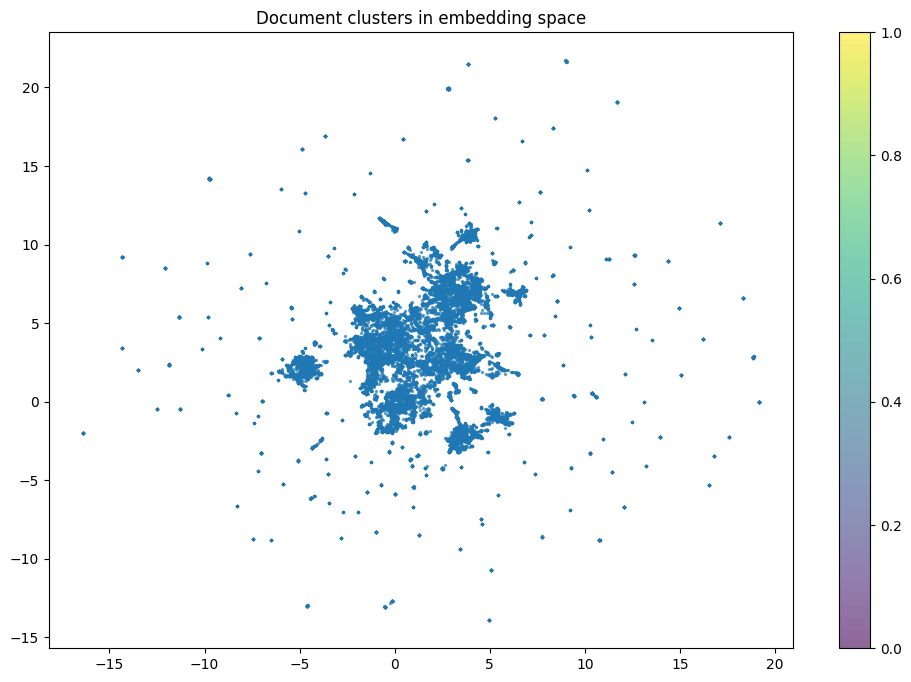

In [77]:
reducer = UMAP(n_components=2, metric='cosine', n_neighbors=10, min_dist=0, random_state=42)
reduced = reducer.fit_transform(embeddings) 

plt.figure(figsize=(12, 8))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], cmap='tab20', s=2, alpha=0.6)
plt.colorbar(scatter)
plt.title("Document clusters in embedding space")
plt.show()

Set UMAP, HDBSCAN, vectorizer and representation model parameters

In [5]:
all_stopwords = SW_EN | SW_DE | SW_FR | SW_ES | SW_IT
vectorizer_model = CountVectorizer(stop_words = list(all_stopwords), min_df = 2, ngram_range = (1, 2))

keybert_model = KeyBERTInspired()
mmr_model = MaximalMarginalRelevance(diversity=0.3)

representation_model = {"KeyBERT": keybert_model, "MMR": mmr_model}

embedding_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
df = df.reset_index(drop=True)
embeddings = np.load("embeddings.npy")
embeddings = embeddings[:len(df)]

In [ ]:
def sweep_subtype(subtype, group, embeddings, 
                  n_components_list=[5, 10, 15],
                  min_cluster_sizes=[10, 20, 30, 50],
                  n_neighbors_list=[10, 15, 20]): 
    
    subtype_embeddings = embeddings[group.index]
    n = len(group)

    results = []
    for n_comp, min_cs, n_nb in itertools.product(n_components_list, min_cluster_sizes, n_neighbors_list):
        umap_model = UMAP(n_components=n_comp, n_neighbors=n_nb,
                          min_dist=0.0, metric="cosine", random_state=42)
        hdbscan_model = HDBSCAN(min_cluster_size=min_cs, min_samples=1,
                                metric="euclidean", cluster_selection_method="eom",
                                prediction_data=True)
        reduced = umap_model.fit_transform(subtype_embeddings)
        labels = hdbscan_model.fit_predict(reduced)
        
        n_topics = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = 100 * (labels == -1).sum() / len(labels)
        counts = pd.Series(labels[labels != -1]).value_counts()
        largest_pct = 100 * counts.iloc[0] / len(labels) if n_topics > 0 else 100.0
        
        # flag combos that look reasonable
        good = (
            5 <= n_topics <= 20 and
            noise_pct < 25 and
            largest_pct < 60
        )
        okay = (
            5 <= n_topics <= 20 and
            noise_pct < 25
        )
        flag = " ✓" if good else (" ?" if okay else "")
        
        print(f"  n_components={n_comp:2d}, min_cluster_size={min_cs:3d} → "
              f"n_neighbors={n_nb:2d} → "
              f"{n_topics:3d} topics, {noise_pct:5.1f}% noise, "
              f"largest {largest_pct:5.1f}%{flag}")
        
        results.append({
            "subtype":           subtype,
            "n_components":      n_comp,
            "min_cluster_size":  min_cs,
            "n_neighbors":       n_nb,
            "n_topics":          n_topics,
            "noise_pct":         noise_pct,
            "largest_topic_pct": largest_pct,
            "good":              good,
            "okay":              okay,
        })
    
    return pd.DataFrame(results)


# run sweep across all subtypes
all_results = []
for subtype, group in df.groupby("subtype"):
    result_df = sweep_subtype(subtype, group, embeddings)
    all_results.append(result_df)

sweep_results = pd.concat(all_results, ignore_index=True)

# summary: best candidate per subtype (most topics among "good" combos)
print("\n" + "="*60)
print("BEST CANDIDATES PER SUBTYPE")
print("="*60)
best = (
    sweep_results[sweep_results["good"]]
    .sort_values(["subtype", "n_topics"], ascending=[True, False])
    .groupby("subtype")
    .first()
    .reset_index()
)[["subtype", "n_components", "min_cluster_size", "n_neighbors", 
   "n_topics", "noise_pct", "largest_topic_pct"]]
sweep_results.to_csv(OUTPUT_PATH / "full_sweep_results.csv", index=False)
best.to_csv(OUTPUT_PATH/"Parameter_combinations.csv", index=False)
print(best.to_string(index=False))

  n_components= 5, min_cluster_size= 10 → n_neighbors=10 → 114 topics,  20.2% noise, largest   2.6%
  n_components= 5, min_cluster_size= 10 → n_neighbors=15 → 103 topics,  18.4% noise, largest   3.0%
  n_components= 5, min_cluster_size= 10 → n_neighbors=20 → 114 topics,  25.1% noise, largest   2.9%
  n_components= 5, min_cluster_size= 20 → n_neighbors=10 →  48 topics,  24.8% noise, largest   8.5%
  n_components= 5, min_cluster_size= 20 → n_neighbors=15 →  47 topics,  21.2% noise, largest   8.4%
  n_components= 5, min_cluster_size= 20 → n_neighbors=20 →  38 topics,  22.0% noise, largest   8.6%
  n_components= 5, min_cluster_size= 30 → n_neighbors=10 →  30 topics,  20.7% noise, largest  11.7%
  n_components= 5, min_cluster_size= 30 → n_neighbors=15 →  26 topics,  20.2% noise, largest  13.3%
  n_components= 5, min_cluster_size= 30 → n_neighbors=20 →  23 topics,  23.3% noise, largest  13.3%
  n_components= 5, min_cluster_size= 50 → n_neighbors=10 →  18 topics,  26.5% noise, largest  12.9%


Run topic model

In [49]:
best = pd.read_csv("Parameter_combinations_reviewed.csv", index_col=None)
aedes_row = pd.DataFrame([{
    "subtype": "Aedes",
    "n_components": 15,
    "min_cluster_size": 30,
    "n_neighbors": 15,
    "n_topics": np.nan,
    "noise_pct": np.nan,
    "largest_topic_pct": np.nan,
}])

culex_row = pd.DataFrame([{
    "subtype": "Culex",
    "n_components": 10,
    "min_cluster_size": 30,
    "n_neighbors": 10,
    "n_topics": np.nan,
    "noise_pct": np.nan,
    "largest_topic_pct": np.nan,
}])

best = pd.concat([best, culex_row], ignore_index=True)
best = pd.concat([best, aedes_row], ignore_index=True)
best_params = (
    best.set_index("subtype")[["n_components", "min_cluster_size", "n_neighbors"]]
    .to_dict(orient="index")
)

df = df.reset_index(drop=True)
embeddings = np.load("embeddings.npy")
embeddings = embeddings[:len(df)]

def build_topic_model_params(subtype_embeddings, subtype, best_params):
    params = best_params[subtype]
    
    umap_model = UMAP(
        n_components=params["n_components"],
        n_neighbors=params["n_neighbors"],
        min_dist=0.0,
        metric="cosine",
        random_state=42,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=params["min_cluster_size"],
        min_samples=1,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )
    return umap_model, hdbscan_model


topic_models = {}
topic_results = {}

for subtype, group in df.groupby("subtype"):
    print(f"\nProcessing {subtype} ({len(group)} documents)...")
    
    abstracts = group["text"].tolist()
    subtype_embeddings = embeddings[group.index]  # works because index == row position
    
    # Build subtype-specific UMAP + HDBSCAN
    umap_model, hdbscan_model = build_topic_model_params(subtype_embeddings, subtype, best_params)
    
    topic_model = BERTopic(
        embedding_model=embedding_model,   # keep the ST model for save/load compatibility
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        calculate_probabilities=True,
        verbose=True,
        top_n_words=10,
    )
    
    # Pass precomputed slice — BERTopic won't re-encode
    topics, probs = topic_model.fit_transform(abstracts, subtype_embeddings)
    
    topic_model.update_topics(
        abstracts,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
    )
    
    topic_model.save(
        f"topic_model_{subtype}",
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model=False,
    )

2026-06-30 23:05:14,354 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Processing Aedes (3157 documents)...


2026-06-30 23:05:27,885 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:05:27,887 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:05:28,113 - BERTopic - Cluster - Completed ✓
2026-06-30 23:05:28,118 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:05:51,073 - BERTopic - Representation - Completed ✓
2026-06-30 23:06:15,127 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-06-30 23:06:15,344 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Processing Chikungunya (2675 documents)...


2026-06-30 23:06:26,259 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:06:26,260 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:06:26,391 - BERTopic - Cluster - Completed ✓
2026-06-30 23:06:26,396 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:06:42,565 - BERTopic - Representation - Completed ✓
2026-06-30 23:07:00,074 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-06-30 23:07:00,266 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

2026-06-30 23:09:09,624 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:09:09,625 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:09:09,728 - BERTopic - Cluster - Completed ✓
2026-06-30 23:09:09,730 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:09:25,013 - BERTopic - Representation - Completed ✓
2026-06-30 23:09:41,232 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-06-30 23:09:41,397 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Processing Zika (2700 documents)...


2026-06-30 23:09:52,499 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:09:52,501 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:09:52,641 - BERTopic - Cluster - Completed ✓
2026-06-30 23:09:52,645 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:10:02,516 - BERTopic - Representation - Completed ✓
2026-06-30 23:10:13,260 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-06-30 23:10:13,432 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Processing anchor (3081 documents)...


2026-06-30 23:10:27,627 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:10:27,630 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:10:27,756 - BERTopic - Cluster - Completed ✓
2026-06-30 23:10:27,761 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:10:41,418 - BERTopic - Representation - Completed ✓
2026-06-30 23:10:56,054 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Investigate model output; especially look at amount of outliers in -1 category

In [3]:
# Load all subtype models
subtypes = ["Aedes", "Chikungunya", "Culex", "Dengue", "Usutu", "West Nile", "Zika", "anchor"]

topic_models = {
    subtype: BERTopic.load(f"topic_model_{subtype}") 
    for subtype in subtypes
}

def get_topic_stats(topic_model, extra_cols=[]):
    topics_info_df = topic_model.get_topic_info().sort_values('Count', ascending=False)
    topics_info_df['Share'] = round(100. * topics_info_df['Count'] / topics_info_df['Count'].sum(), 2)
    topics_info_df['CumulativeShare'] = round(100. * topics_info_df['Count'].cumsum() / topics_info_df['Count'].sum(), 2)
    cols = ['Topic', 'Count', 'Share', 'CumulativeShare', 'Name', 'Representation'] + extra_cols
    return topics_info_df[[c for c in cols if c in topics_info_df.columns]]

# Build a dict of topic info per subtype
topic_infos = {}
for subtype, model in topic_models.items():
    try:
        ti = get_topic_stats(model, ['KeyBERT', 'MMR']).set_index('Topic')
        ti['Topic'] = ti.index
        ti['Subtype'] = subtype
        topic_infos[subtype] = ti
        print(f"{subtype}: {len(ti)} topics")
    except Exception as e:
        print(f"{subtype}: failed — {e}")

# Optional: combined view across all subtypes
all_topic_info = pd.concat(topic_infos.values()).reset_index(drop=True)
all_topic_info

2026-07-13 18:37:54,174 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.
2026-07-13 18:37:54,286 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.
2026-07-13 18:37:54,364 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.
2026-07-13 18:37:54,459 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my

Aedes: 28 topics
Chikungunya: 18 topics
Culex: 16 topics
Dengue: 20 topics
Usutu: 21 topics
West Nile: 18 topics
Zika: 10 topics
anchor: 14 topics


,Count,Share,CumulativeShare,Name,Representation,KeyBERT,MMR,Topic,Subtype
0,727,23.03,23.03,-1_deutschland_menschen_corona_mosquito,"[deutschland, menschen, corona, mosquito, tigr...","[tiere deutschland, gefährlichsten, gefährlich...","[deutschland, dengue, mosquitos, mosquito tigr...",-1,Aedes
1,317,10.04,33.07,0_mücken_mosquitos_mosquito_tigre,"[mücken, mosquitos, mosquito, tigre, insekten,...","[stechmücken, mücken, insetti, insekten, moust...","[mücken, mosquitos, mosquito, stechmücken, mou...",0,Aedes
2,266,8.43,41.50,1_zika_virus_2016_virus zika,"[zika, virus, 2016, virus zika, cas, été, keys...","[épidémie zika, virus zika, zika virus, zika é...","[zika, virus zika, zika virus, février 2016, b...",1,Aedes
3,204,6.46,47.96,2_dengue_zanzara_disinfestazione_malattia,"[dengue, zanzara, disinfestazione, malattia, f...","[cas dengue, dengue fieber, febbre dengue, den...","[dengue, zanzara, febbre, zanzare, virus, ital...",2,Aedes
4,138,4.37,52.33,3_chikungunya_cas_virus_été,"[chikungunya, cas, virus, été, réunion, santé,...","[épidémie chikungunya, chikungunya été, virus ...","[chikungunya, cas, virus, santé, épidémie, chi...",3,Aedes
...,...,...,...,...,...,...,...,...,...
140,76,2.47,91.37,8_lengua_lengua azul_azul_enfermedad,"[lengua, lengua azul, azul, enfermedad, ganade...","[castilla mancha, vacuna, españa, vacunar, vac...","[lengua azul, enfermedad, ganaderos, vacunació...",8,anchor
141,72,2.34,93.70,9_antarktis_insekt_larven_ámbar,"[antarktis, insekt, larven, ámbar, millones añ...","[mosquito, mosquitos, insekten, insekt, larven...","[insekt, larven, forscher, mosquitos, belgica ...",9,anchor
142,70,2.27,95.98,10_zigaretten_verbot_produkte_metall,"[zigaretten, verbot, produkte, metall, deutsch...","[rauchen, tabak, zigaretten, beliebt, dampf, p...","[zigaretten, deutschland, euro, ig metall, fra...",10,anchor
143,65,2.11,98.09,11_vigilancia_nilo_mosquitos_virus,"[vigilancia, nilo, mosquitos, virus, salud, co...","[mosquito, mosquitos, fiebre nilo, virus nilo,...","[mosquitos, virus, virus nilo, riesgo, salud p...",11,anchor


In [11]:
topic_infos["Usutu"]

,Count,Share,CumulativeShare,Name,Representation,KeyBERT,MMR,Topic,Subtype
Topic,,,,,,,,,
0,147,21.59,21.59,0_vögel_stunde_wintervögel_gärten,"[vögel, stunde, wintervögel, gärten, garten, n...","[wintervögel, stunde wintervögel, vogelzählung...","[vögel, wintervögel, gärten, garten, stunde wi...",0,Usutu
1,93,13.66,35.24,1_nabu_amseln_usutu_vögel,"[nabu, amseln, usutu, vögel, virus, usutu viru...","[vogelsterben, meisensterben, sterben, kranke ...","[amseln, virus, usutu virus, deutschland, stec...",1,Usutu
-1,69,10.13,45.37,-1_virus_basel_tauben_usutu,"[virus, basel, tauben, usutu, virus usutu, feb...","[krankheit, kranken, erkrankte, vögel gemeldet...","[virus, tauben, virus usutu, febbre, zanzare, ...",-1,Usutu
2,43,6.31,51.69,2_presidente_euros_partido_años,"[presidente, euros, partido, años, investigaci...","[suárez, pérez llorca, pérez, españa, valencia...","[presidente, euros, investigación, pp, noticia...",2,Usutu
3,37,5.43,57.12,3_west nile_nile_west_virus,"[west nile, nile, west, virus, veneto, emilia,...","[nile virus, infezione west, virus usutu, viru...","[west nile, virus, zanzare, emilia romagna, fe...",3,Usutu
4,29,4.26,61.38,4_enfermedad_virus_arbovirus_enfermedades,"[enfermedad, virus, arbovirus, enfermedades, d...","[epidemias, pandemia, enfermedades, peligro, i...","[virus, arbovirus, dengue, zika, humanos, mosq...",4,Usutu
5,28,4.11,65.49,5_moustique_virus_été_moustiques,"[moustique, virus, été, moustiques, cas, moust...","[transmis moustique, dengue chikungunya, dengu...","[virus, moustiques, moustique tigre, encéphali...",5,Usutu
6,28,4.11,69.60,6_sangre_banco sangre_mallorca_banco,"[sangre, banco sangre, mallorca, banco, infecc...","[usutu arbovirus, infecciones usutu, virus usu...","[sangre, banco sangre, infecciones, virus, vir...",6,Usutu
7,22,3.23,72.83,7_vogel jahres_rebhuhn_jahres_vogel,"[vogel jahres, rebhuhn, jahres, vogel, kandida...","[naturschutz bayern, federpuscheln kopf, wiese...","[vogel jahres, rebhuhn, waldohreule, zwergtauc...",7,Usutu


Extract top abstracts and representative words for each topic and store as new csv file

In [17]:
abstracts_dict = (
    df.groupby("subtype")["text"]
      .apply(list)
      .to_dict()
)

# Create output folder
output_dir = OUTPUT_PATH/"Sample_stories.csv"
os.makedirs(output_dir, exist_ok=True)

for subtype, topic_model in topic_models.items():

    print(f"Processing {subtype}...")

    abstracts = abstracts_dict[subtype]

    # Topic info
    topic_info = topic_model.get_topic_info()

    # Document information
    doc_info = topic_model.get_document_info(abstracts)
    assert "Document" in doc_info.columns

    # Find probability column (if present)
    probability_col = None
    for col in doc_info.columns:
        if col.lower().startswith("prob"):
            probability_col = col
            break

    # Sort documents by topic and probability
    if probability_col is not None:
        doc_info = doc_info.sort_values(
            ["Topic", probability_col],
            ascending=[True, False]
        )
    else:
        doc_info = doc_info.sort_values(["Topic"])

    # Get top 10 documents per topic
    top_docs_per_topic = {}
    for topic_id in sorted(doc_info["Topic"].unique()):
        if topic_id == -1:
            continue

        topic_docs = doc_info[doc_info["Topic"] == topic_id]
        top_docs_per_topic[topic_id] = topic_docs["Document"].head(10).tolist()

    # Topic representations
    rows = []
    representations = topic_model.topic_aspects_

    for topic_id in topic_info["Topic"]:

        if topic_id == -1:
            continue

        keybert_repr = representations.get("KeyBERT", {}).get(topic_id, [])
        mmr_repr = representations.get("MMR", {}).get(topic_id, [])

        keybert_words = ", ".join(word for word, _ in keybert_repr)
        mmr_words = ", ".join(word for word, _ in mmr_repr)

        top_abstracts = top_docs_per_topic.get(topic_id, [])

        row = {
            "Topic": topic_id,
            "Topic_Name": topic_info.loc[
                topic_info["Topic"] == topic_id, "Name"
            ].iloc[0],
            "KeyBERT_Representation": keybert_words,
            "MMR_Representation": mmr_words,
        }

        # Add Abstract_1 ... Abstract_10
        for i in range(10):
            row[f"Abstract_{i+1}"] = (
                top_abstracts[i] if i < len(top_abstracts) else ""
            )

        rows.append(row)

    topics_export_df = pd.DataFrame(rows)

    output_file = os.path.join(
        output_dir,
        f"{subtype}_topic_representations_and_abstracts.csv"
    )

    topics_export_df.to_excel(
    os.path.join(output_dir, f"{subtype}_topic_representations_and_abstracts.xlsx"),
    index=False,
    )

    print(f"Saved {output_file}")

print("All CSVs exported successfully.")

Processing Aedes...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Aedes_topic_representations_and_abstracts.csv
Processing Chikungunya...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Chikungunya_topic_representations_and_abstracts.csv
Processing Culex...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Culex_topic_representations_and_abstracts.csv
Processing Dengue...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Dengue_topic_representations_and_abstracts.csv
Processing Usutu...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Us

Draw similarity matrix to see which topics are so similar that we might actually be able to group them

In [20]:
for subtype, topic_model in topic_models.items():
    print(subtype)

    n_topics = (topic_model.get_topic_info()["Topic"] != -1).sum()

    fig = topic_model.visualize_heatmap(
        n_clusters=max(2, n_topics - 1)
    )

    display(fig)

Aedes


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>Similarity Score: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'x': [0_mücken_mosquitos_mosquito, 1_zika_virus_2016,
                    2_dengue_zanzara_disinfesta..., 3_chikungunya_cas_virus,
                    4_gobierno_euros_pp, 5_tigermücke_basel_tigermüc...,
                    6_noticias_relacionadas_not..., 7_tigermücke_tigermücken_as...,
                    8_acqua_aree_tigre, 9_mosquito_mosquito tigre_m...,
                    10_grad_klimawandel_menschen, 11_männchen_moustiques_mous...,
                    12_virus_malaria_dengue, 13_dengue_cas_fieber,
                    14_österreich_tigermücke_st..., 15_especies_arten_exóticas,
                    16_moustique_moustique tigr..., 17_moustique_moustique tigr...,
                    18_dengue_virus_denguefieber, 19_mosquito_mosquito tigre_...,
                    20_hornisse_hornissen_espèces, 21_deutschland_chikungunya_...,
                    22_dengue_europa_fälle, 23_zürich_franken_zürcher,
                    24_curso_plazas_alumnos, 25_valneva_chikungunya_vaccin,
                    26_mücken_hausmittel_mücken...],
              'xaxis': 'x',
              'y': [0_mücken_mosquitos_mosquito, 1_zika_virus_2016,
                    2_dengue_zanzara_disinfesta..., 3_chikungunya_cas_virus,
                    4_gobierno_euros_pp, 5_tigermücke_basel_tigermüc...,
                    6_noticias_relacionadas_not..., 7_tigermücke_tigermücken_as...,
                    8_acqua_aree_tigre, 9_mosquito_mosquito tigre_m...,
                    10_grad_klimawandel_menschen, 11_männchen_moustiques_mous...,
                    12_virus_malaria_dengue, 13_dengue_cas_fieber,
                    14_österreich_tigermücke_st..., 15_especies_arten_exóticas,
                    16_moustique_moustique tigr..., 17_moustique_moustique tigr...,
                    18_dengue_virus_denguefieber, 19_mosquito_mosquito tigre_...,
                    20_hornisse_hornissen_espèces, 21_deutschland_chikungunya_...,
                    22_dengue_europa_fälle, 23_zürich_franken_zürcher,
                    24_curso_plazas_alumnos, 25_valneva_chikungunya_vaccin,
                    26_mücken_hausmittel_mücken...],
              'yaxis': 'y',
              'z': {'bdata': ('AACAPxSeMT9CIjg/ChknPy0I/j7bB0' ... 'EtP0KeJj8d1Kw+3o7QPrva+z7+/38/'),
                    'dtype': 'f4',
                    'shape': '27, 27'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'colorbar': {'title': {'text': 'Similarity Score'}},
                             'colorscale': [[0.0, 'rgb(247,252,240)'], [0.125,
                                            'rgb(224,243,219)'], [0.25,
                                            'rgb(204,235,197)'], [0.375,
                                            'rgb(168,221,181)'], [0.5,
                                            'rgb(123,204,196)'], [0.625,
                                            'rgb(78,179,211)'], [0.75,
                                            'rgb(43,140,190)'], [0.875,
                                            'rgb(8,104,172)'], [1.0,
                                            'rgb(8,64,129)']]},
               'height': 800,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'title': {'text': 'Trend'}},
               'margin': {'t': 60},
               'showlegend': True,
               'template': '...',
               'title': {'font': {'color': 'Black', 'size': 22},
                         'text': '<b>Similarity Matrix</b>',
                         'x': 0.55,
                         'xanchor': 'center',
                         'y': 0.95,
                         'yanchor': 'top'},
               'width': 800,
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.

Chikungunya


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

...

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>Similarity Score: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'x': [0_rio_zika_2016, 1_zika_virus_zika virus, 5_zika_virus_oms,
                    2_virus_covid_coronavirus, 3_mosquitos_tigre_mosquito,
                    4_2016_zika_virus, 6_dengue_virus_chikungunya,
                    7_cambio_climático_cambio c..., 8_virus_impfstoff_zika],
              'xaxis': 'x',
              'y': [0_rio_zika_2016, 1_zika_virus_zika virus, 5_zika_virus_oms,
                    2_virus_covid_coronavirus, 3_mosquitos_tigre_mosquito,
                    4_2016_zika_virus, 6_dengue_virus_chikungunya,
                    7_cambio_climático_cambio c..., 8_virus_impfstoff_zika],
              'yaxis': 'y',
              'z': {'bdata': ('AACAP81hJj8GSC4/zLQsP6r5HD/Xbw' ... '1eP0AtPT89clE/RyhAPyegID8AAIA/'),
                    'dtype': 'f4',
                    'shape': '9, 9'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'colorbar': {'title': {'text': 'Similarity Score'}},
                             'colorscale': [[0.0, 'rgb(247,252,240)'], [0.125,
                                            'rgb(224,243,219)'], [0.25,
                                            'rgb(204,235,197)'], [0.375,
                                            'rgb(168,221,181)'], [0.5,
                                            'rgb(123,204,196)'], [0.625,
                                            'rgb(78,179,211)'], [0.75,
                                            'rgb(43,140,190)'], [0.875,
                                            'rgb(8,104,172)'], [1.0,
                                            'rgb(8,64,129)']]},
               'height': 800,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'title': {'text': 'Trend'}},
               'margin': {'t': 60},
               'showlegend': True,
               'template': '...',
               'title': {'font': {'color': 'Black', 'size': 22},
                         'text': '<b>Similarity Matrix</b>',
                         'x': 0.55,
                         'xanchor': 'center',
                         'y': 0.95,
                         'yanchor': 'top'},
               'width': 800,
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.0, 1.0], 'scaleanchor': 'y'},
               'yaxis': {'anchor': 'x', 'autorange': 'reversed', 'constrain': 'domain', 'domain': [0.0, 1.0]}}
})

anchor


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>Similarity Score: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'x': [0_mücke_euro_zanzara, 1_mücken_moustiques_peces,
                    2_cas_chikungunya_dengue, 11_vigilancia_nilo_mosquitos,
                    3_virus_west_casos, 4_dembélé_psg_lamine,
                    5_euros_millones_cambio, 6_malaria_anopheles_mücken,
                    7_25_set_punti, 8_lengua_lengua azul_azul,
                    9_antarktis_insekt_larven, 10_zigaretten_verbot_produkte,
                    12_moustique_tigre_tigermücke],
              'xaxis': 'x',
              'y': [0_mücke_euro_zanzara, 1_mücken_moustiques_peces,
                    2_cas_chikungunya_dengue, 11_vigilancia_nilo_mosquitos,
                    3_virus_west_casos, 4_dembélé_psg_lamine,
                    5_euros_millones_cambio, 6_malaria_anopheles_mücken,
                    7_25_set_punti, 8_lengua_lengua azul_azul,
                    9_antarktis_insekt_larven, 10_zigaretten_verbot_produkte,
                    12_moustique_tigre_tigermücke],
              'yaxis': 'y',
              'z': {'bdata': ('AQCAP7zkFz9ZTfY+C97ePhT5ET8YCQ' ... '9L5so+USc3PyQfJD+mkNE+AQCAPw=='),
                    'dtype': 'f4',
                    'shape': '13, 13'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'colorbar': {'title': {'text': 'Similarity Score'}},
                             'colorscale': [[0.0, 'rgb(247,252,240)'], [0.125,
                                            'rgb(224,243,219)'], [0.25,
                                            'rgb(204,235,197)'], [0.375,
                                            'rgb(168,221,181)'], [0.5,
                                            'rgb(123,204,196)'], [0.625,
                                            'rgb(78,179,211)'], [0.75,
                                            'rgb(43,140,190)'], [0.875,
                                            'rgb(8,104,172)'], [1.0,
                                            'rgb(8,64,129)']]},
               'height': 800,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'title': {'text': 'Trend'}},
               'margin': {'t': 60},
               'showlegend': True,
               'template': '...',
               'title': {'font': {'color': 'Black', 'size': 22},
                         'text': '<b>Similarity Matrix</b>',
                         'x': 0.55,
                         'xanchor': 'center',
                         'y': 0.95,
                         'yanchor': 'top'},
               'width': 800,
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.0, 1.0], 'scaleanchor': 'y'},
               'yaxis': {'anchor': 'x', 'autorange': 'reversed', 'constrain': 'domain', 'domain': [0.0, 1.0]}}
})

Calculate pair distances. This suggests pairs of topics we could merge if the top words are close or exact matches

In [24]:
output_dir = OUTPUT_PATH/"bertopic_topic_distances"
os.makedirs(output_dir, exist_ok=True)

all_pair_distances = {}

for subtype, topic_model in topic_models.items():

    print(f"Processing {subtype}...")

    # Pairwise cosine similarity between topic embeddings
    distance_matrix = cosine_similarity(np.array(topic_model.topic_embeddings_))

    labels = list(topic_model.topic_labels_.values())

    dist_df = pd.DataFrame(
        distance_matrix,
        index=labels,
        columns=labels
    )

    tmp = []

    for rec in dist_df.reset_index().to_dict("records"):
        topic1 = rec["index"]

        for topic2 in rec:
            if topic2 == "index":
                continue

            tmp.append({
                "topic1": topic1,
                "topic2": topic2,
                "similarity": rec[topic2]
            })

    pair_dist_df = pd.DataFrame(tmp)

    # Remove outlier topic (-1)
    pair_dist_df = pair_dist_df[
        (~pair_dist_df["topic1"].str.startswith("-1")) &
        (~pair_dist_df["topic2"].str.startswith("-1"))
    ]

    # Keep each pair only once
    pair_dist_df = pair_dist_df[
        pair_dist_df["topic1"] < pair_dist_df["topic2"]
    ]

    # Highest similarity first
    pair_dist_df = pair_dist_df.sort_values(
        "similarity",
        ascending=False
    ).reset_index(drop=True)

    pair_dist_df = pair_dist_df.head(20)

    # Save
    outfile = os.path.join(
        output_dir,
        f"{subtype}_topic_similarities.csv"
    )
    pair_dist_df.to_csv(outfile, index=False)

    all_pair_distances[subtype] = pair_dist_df

    print(f"Top 10 most similar topic pairs for {subtype}:")
    print(pair_dist_df.head(10))
    print()

print("Finished exporting all topic similarity tables.")

Processing Aedes...
Top 10 most similar topic pairs for Aedes:
                                            topic1  \
0               13_dengue_cas_fieber_dengue fieber   
1    16_moustique_moustique tigre_tigre_moustiques   
2     21_deutschland_chikungunya_dengue_tigermücke   
3        5_tigermücke_basel_tigermücken_asiatische   
4               18_dengue_virus_denguefieber_aedes   
5               13_dengue_cas_fieber_dengue fieber   
6               13_dengue_cas_fieber_dengue fieber   
7  19_mosquito_mosquito tigre_tigre_mosquito alert   
8  14_österreich_tigermücke_stechmücken_asiatische   
9                15_especies_arten_exóticas_specie   

                                              topic2  similarity  
0          2_dengue_zanzara_disinfestazione_malattia    0.936730  
1      17_moustique_moustique tigre_tigre_moustiques    0.935427  
2                 22_dengue_europa_fälle_infektionen    0.933518  
3  7_tigermücke_tigermücken_asiatische_asiatische...    0.931990  
4      

Merge similar topics

In [7]:
# 1. Load the final mapping csv
mapping_df = pd.read_csv("Sample_stories/00_final_topic_names_MED.csv")
mapping_df["source_spreadsheet"] = mapping_df["source_spreadsheet"].replace({"Mosquito": "anchor"})

# sanity check: do source_spreadsheet values match your subtypes?
print(mapping_df["source_spreadsheet"].unique())
print(df["subtype"].unique())

# 2. Build merge groups + labels per subtype
merge_groups_per_subtype = {}
topic_labels_per_subtype = {}
topic_id_remap_per_subtype = {}   # NEW

for subtype, group in mapping_df.groupby("source_spreadsheet"):
    groups_to_merge = []
    labels = {}
    id_remap = {}   # NEW: orig_id -> surviving_id, for every topic incl. singletons

    for final_name, topics in group.groupby("final_topic_name"):
        topic_ids = topics["Topic"].tolist()
        topic_ids = [t for t in topic_ids if t >= 0]
        if not topic_ids:
            continue

        if len(topic_ids) > 1:
            groups_to_merge.append(topic_ids)

        surviving_id = min(topic_ids)
        labels[surviving_id] = final_name
        for t in topic_ids:                # NEW
            id_remap[t] = surviving_id      # NEW

    merge_groups_per_subtype[subtype] = groups_to_merge
    topic_labels_per_subtype[subtype] = labels
    topic_id_remap_per_subtype[subtype] = id_remap   # NEW


# quick sanity check on group sizes before running anything
for subtype, groups in merge_groups_per_subtype.items():
    print(subtype, [len(g) for g in groups])

<ArrowStringArray>
[      'Aedes', 'Chikungunya',       'Culex',      'Dengue',      'anchor',
       'Usutu',   'West Nile',        'Zika']
Length: 8, dtype: str
<ArrowStringArray>
[      'Aedes', 'Chikungunya',      'Dengue',   'West Nile',        'Zika',
       'Culex',       'Usutu',      'anchor']
Length: 8, dtype: str
Aedes [2, 3, 2, 2, 3]
Chikungunya [2, 2]
Culex [2, 8]
Dengue [2, 2]
Usutu [4, 2, 3, 3]
West Nile [2, 7]
Zika [2]
anchor [2]


In [8]:
# 3. Apply merges to each loaded model, save updated versions
topic_models = {
    subtype: BERTopic.load(f"topic_model_{subtype}", embedding_model=embedding_model)
    for subtype in subtypes
}

df = df.reset_index(drop=True)  # keep this consistent with your original indexing

for subtype, topic_model in topic_models.items():
    if subtype not in merge_groups_per_subtype:
        print(f"{subtype}: no mapping found, skipping")
        continue
    
    group = df[df["subtype"] == subtype]
    abstracts = group["text"].tolist()
    
    groups_to_merge = merge_groups_per_subtype[subtype]
    
    if groups_to_merge:
        topic_model.merge_topics(abstracts, groups_to_merge)
    
    # write merged topic ids back into df, aligned on the right rows
    df.loc[group.index, "merged_topic"] = topic_model.topics_
    
    topic_model.update_topics(
        abstracts,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
    )
    
    # apply your final_topic_name labels
    topic_model.set_topic_labels(topic_labels_per_subtype[subtype])
    
    # save the merged model back to disk
    topic_model.save(
        f"topic_model_{subtype}_merged",
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model=False,
    )
    
    print(f"{subtype}: merged {len(groups_to_merge)} groups, "
          f"{topic_model.get_topic_info().shape[0]} topics remain")

2026-07-03 18:51:16,170 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Aedes: merged 5 groups, 21 topics remain


2026-07-03 18:51:54,602 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Chikungunya: merged 2 groups, 16 topics remain


2026-07-03 18:52:13,117 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


...

West Nile: merged 2 groups, 11 topics remain


2026-07-03 18:54:09,885 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Zika: merged 1 groups, 9 topics remain


2026-07-03 18:54:42,742 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


anchor: merged 1 groups, 13 topics remain


In [9]:
# delete irrelevant topics and documents
mapping_df["Delete?"] = mapping_df["Delete?"].fillna("n")

delete_ids_per_subtype = {
    subtype: [
        topic_id_remap_per_subtype.get(subtype, {}).get(t, t)
        for t in group.loc[group["Delete?"].str.lower() == "y", "Topic"].tolist()
    ]
    for subtype, group in mapping_df.groupby("source_spreadsheet")
}

df = df.reset_index(drop=True)  # keep consistent indexing throughout
df_clean_parts = []

for subtype, topic_model in topic_models.items():
    delete_ids = delete_ids_per_subtype.get(subtype, [])
    
    group = df[df["subtype"] == subtype].reset_index(drop=False)  # keep original df index
    abstracts = group["text"].tolist()
    current_topics = topic_model.topics_  # order matches abstracts, IF df hasn't been reordered since fit

    assert len(current_topics) == len(abstracts), f"{subtype}: mismatch — topics_ length doesn't match df order"

    keep_mask = [t not in delete_ids for t in current_topics]
    dropped_n = len(abstracts) - sum(keep_mask)
    print(f"{subtype}: dropping {dropped_n} documents from {len(delete_ids)} deleted topic(s)")

    kept_abstracts = [a for a, k in zip(abstracts, keep_mask) if k]
    kept_topics    = [t for t, k in zip(current_topics, keep_mask) if k]
    kept_orig_idx  = group.loc[keep_mask, "index"]

    # refresh topic representations using ONLY the surviving docs
    topic_model.update_topics(
        kept_abstracts,
        topics=kept_topics,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        ctfidf_model=None
    )

    # Re-apply labels, since update_topics may reset them
    topic_model.set_topic_labels(topic_labels_per_subtype[subtype])
    topic_model.topic_aspects_ = {}

    # Save the cleaned model
    topic_model.save(
        f"topic_model_{subtype}_merged",
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model=False,
    )

    df_clean_parts.append(df.loc[kept_orig_idx])

df_clean = pd.concat(df_clean_parts).sort_index()

# check number of docs after deletion step
for subtype, topic_model in topic_models.items():
    info = topic_model.get_topic_info()
    total_docs = info["Count"].sum()
    print(f"{subtype}: {total_docs} documents across {len(info)} topics")

2026-07-03 18:54:50,657 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Aedes: dropping 265 documents from 4 deleted topic(s)


2026-07-03 18:55:29,006 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-07-03 18:55:29,347 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Chikungunya: dropping 142 documents from 3 deleted topic(s)


2026-07-03 18:55:57,391 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-07-03 18:55:57,707 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


...

Zika: dropping 0 documents from 0 deleted topic(s)


2026-07-03 18:57:38,705 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-07-03 18:57:38,982 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


anchor: dropping 1710 documents from 6 deleted topic(s)


2026-07-03 18:57:53,283 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Aedes: 2892 documents across 19 topics
Chikungunya: 2533 documents across 14 topics
Culex: 2101 documents across 8 topics
Dengue: 2546 documents across 12 topics
Usutu: 585 documents across 10 topics
West Nile: 1577 documents across 10 topics
Zika: 2700 documents across 9 topics
anchor: 1371 documents across 7 topics


Inspect outliers

In [102]:
for subtype, topic_model in topic_models.items():
    group = df[df["subtype"] == subtype]
    abstracts = group["text"].tolist()
    topics = topic_model.topics_

    outlier_docs = [doc for doc, t in zip(abstracts, topics) if t == -1]

    print(f"\n{'='*60}")
    print(f"{subtype}: {len(outlier_docs)} outlier documents")
    print(f"{'='*60}")

    for doc in outlier_docs[:20]:
        print("-", doc)
        print()


Aedes: 727 outlier documents
- Insekten bringen Krankheiten nach Europa, die es bisher nicht gab.
Tropische Stechmücken wie die Asiatische Tigermücke gelangten auch schon in der Vergangenheit mit Warenlieferungen oder im Gepäck von Touristen nach Europa. Früher verendeten diese Insekten rasch im für sie unwirtlichen Klima: zu kalt. Doch der Klimawandel bringt mit sich, dass die Tiere hier zunehmend günstige Lebensbedingungen vorfinden, sodass sie sich vermehren können und mittlerweile schon große Populationen produzieren.
Fazit: In weiten Teilen Südeuropas, in Österreich, Frankreich und Deutschland existieren mittlerweile stabile Populationen tropischer Mücken. Fatal daran ist, dass die kleinen Reisenden typische tropische Krankheiten im Gepäck mitbrachten, die es bisher in Europa nicht gab. Die Forscher gehen davon aus, dass sich zwei Drittel dieser Erkrankungen infolge des Klimawandels mit ziemlicher Sicherheit weiter ausbreiten werden.
Natürlich muss man wegen dieser Entwicklung (n

Reassign outliers to topics or label as interdisciplinary

In [10]:
def label_interdisciplinary_outliers(
    topic_model,
    df_clean,
    text_col="text",
    subtype_col="subtype",
    subtype=None,
    multi_threshold=0.2,
    min_topics_above=2,
    rescue_threshold=0.3,
):
    """
    Labels outliers using probability structure on the *final cleaned dataset*.

    IMPORTANT:
    - Only df_clean is modified.
    - The original df (full dataset) is never touched.
    """

    # Work on a copy of df_clean so we can safely modify it
    df_updated = df_clean.copy()

    # -----------------------------
    # 1. Subtype filtering
    # -----------------------------
    if subtype is not None:
        df_sub = df_updated[df_updated[subtype_col] == subtype].copy()
    else:
        df_sub = df_updated.copy()

    # Keep original index for writing back
    df_sub = df_sub.reset_index(drop=False)

    # Guard: alignment between df_sub and topic_model.topics_ depends on both
    # being in ascending original-index order. Nothing enforces this upstream,
    # so make it explicit here rather than relying on coincidence.
    assert df_sub["index"].is_monotonic_increasing, (
        f"{subtype}: df_sub is not in ascending original-index order — "
        "alignment with topic_model.topics_ may be wrong"
    )

    abstracts = df_sub[text_col].tolist()
    topics = np.array(topic_model.topics_)

    # -----------------------------
    # 2. Sanity check
    # -----------------------------
    if len(topics) != len(df_sub):
        raise ValueError(
            f"Mismatch: topic_model.topics_ ({len(topics)}) "
            f"vs df_sub ({len(df_sub)}). Ensure df_clean matches the model."
        )

    # -----------------------------
    # 3. Identify outliers
    # -----------------------------
    outlier_indices = np.where(topics == -1)[0]

    if len(outlier_indices) == 0:
        # No outliers -> return df_clean unchanged
        return df_updated, pd.DataFrame(), {"n_outliers": 0}

    outlier_docs = [abstracts[i] for i in outlier_indices]

    # -----------------------------
    # 4. Probability distribution
    # -----------------------------
    topic_distr, _ = topic_model.approximate_distribution(
        outlier_docs,
        window=4,
        calculate_tokens=True
    )

    # approximate_distribution's columns correspond to this model's own sorted
    # list of surviving (non-outlier) topic ids -- NOT raw 0..n-1 integers.
    # After merge_topics()/delete steps, ids are no longer contiguous, so
    # probs.argmax() must be translated back through this mapping.
    topic_ids_sorted = sorted(t for t in set(topic_model.topics_) if t != -1)

    # -----------------------------
    # 5. Labeling logic
    # -----------------------------
    new_topics = topics.copy()

    outcomes = []
    max_probs = []
    n_multi_list = []

    for j, orig_i in enumerate(outlier_indices):
        probs = topic_distr[j]

        max_prob = probs.max()
        max_probs.append(max_prob)

        n_above = (probs > multi_threshold).sum()
        n_multi_list.append(n_above)

        if n_above >= min_topics_above:
            new_topics[orig_i] = -2
            outcomes.append("interdisciplinary")

        elif max_prob > rescue_threshold:
            new_topics[orig_i] = topic_ids_sorted[int(probs.argmax())]
            outcomes.append("reassigned")

        else:
            outcomes.append("true_outlier")

    # -----------------------------
    # 6. Write back ONLY to df_clean
    # -----------------------------
    df_sub["topic_label"] = new_topics

    # Write back using original df_clean indices
    df_updated.loc[df_sub["index"], "topic_label"] = df_sub["topic_label"].values

    # -----------------------------
    # 7. Outlier table
    # -----------------------------
    outlier_df = pd.DataFrame({
        "document": outlier_docs,
        "topic_original": [-1] * len(outlier_indices),
        "topic_new": [new_topics[i] for i in outlier_indices],
        "max_prob": max_probs,
        "n_topics_above_threshold": n_multi_list,
        "outcome": outcomes
    })

    # -----------------------------
    # 8. Summary
    # -----------------------------
    summary = {
        "n_outliers": len(outlier_indices),
        "n_interdisciplinary": sum(o == "interdisciplinary" for o in outcomes),
        "n_reassigned": sum(o == "reassigned" for o in outcomes),
        "n_true_outliers": sum(o == "true_outlier" for o in outcomes),
    }

    return df_updated, outlier_df, summary


# -----------------------------
# Run reassignment across all subtypes
# -----------------------------
topic_models = {
    subtype: BERTopic.load(f"topic_model_{subtype}_merged", embedding_model=embedding_model)
    for subtype in subtypes
}

all_outliers = []
stats = {}

for subtype, model in topic_models.items():
    df_clean, outlier_df, summary = label_interdisciplinary_outliers(
        model,
        df_clean,
        subtype=subtype
    )

    all_outliers.append(outlier_df)
    stats[subtype] = summary

outlier_df_all = pd.concat(all_outliers, ignore_index=True)
outlier_df_all.to_csv(OUTPUT_PATH / "outlier_reassignment.csv", index=False)

100%|██████████| 1/1 [00:04<00:00,  4.24s/it]


Perform second-pass approach to check that remaining true outliers aren't a missed topic - high or unstable outlier rate and poor clustering after second model run would indicate outliers are true outliers

In [106]:
second_pass_docs = {}
second_pass_models = {}
second_pass_results = {}

for subtype, topic_model in topic_models.items():

    print(f"\n--- Processing {subtype} ---")

    group = df_clean[df_clean["subtype"] == subtype]
    abstracts = group["text"].tolist()

    topics = np.array(topic_model.topics_)

    if len(topics) != len(abstracts):
        raise ValueError(f"{subtype}: mismatch topics vs docs")

    true_outlier_indices = np.where(topics == -1)[0]

    if len(true_outlier_indices) == 0:
        print(f"{subtype}: no true outliers")
        continue

    true_outlier_abstracts = [abstracts[i] for i in true_outlier_indices]
    true_outlier_embeddings = embeddings[group.index[true_outlier_indices]]

    topic_model_outliers = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        min_topic_size=5,
        verbose=True
    )

    outlier_topics, outlier_probs = topic_model_outliers.fit_transform(
        true_outlier_abstracts,
        embeddings=true_outlier_embeddings
    )

    # ✅ CRITICAL FIX: store docs for later visualization
    second_pass_docs[subtype] = true_outlier_abstracts
    topic_model_outliers._original_docs = true_outlier_abstracts

    second_pass_models[subtype] = topic_model_outliers

2026-07-03 17:45:44,913 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



--- Processing Aedes ---


2026-07-03 17:45:45,695 - BERTopic - Dimensionality - Completed ✓
2026-07-03 17:45:45,697 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-03 17:45:45,743 - BERTopic - Cluster - Completed ✓
2026-07-03 17:45:45,749 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-03 17:46:18,897 - BERTopic - Representation - Completed ✓
2026-07-03 17:46:19,342 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



--- Processing Chikungunya ---


2026-07-03 17:46:19,990 - BERTopic - Dimensionality - Completed ✓
2026-07-03 17:46:19,991 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-03 17:46:20,017 - BERTopic - Cluster - Completed ✓
2026-07-03 17:46:20,022 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-03 17:46:42,033 - BERTopic - Representation - Completed ✓
2026-07-03 17:46:42,463 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

2026-07-03 17:48:13,677 - BERTopic - Dimensionality - Completed ✓
2026-07-03 17:48:13,678 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-03 17:48:13,697 - BERTopic - Cluster - Completed ✓
2026-07-03 17:48:13,702 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-03 17:48:35,989 - BERTopic - Representation - Completed ✓
2026-07-03 17:48:36,304 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



--- Processing Zika ---


2026-07-03 17:48:36,636 - BERTopic - Dimensionality - Completed ✓
2026-07-03 17:48:36,638 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-03 17:48:36,656 - BERTopic - Cluster - Completed ✓
2026-07-03 17:48:36,661 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-03 17:49:00,998 - BERTopic - Representation - Completed ✓
2026-07-03 17:49:01,293 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



--- Processing anchor ---


2026-07-03 17:49:01,984 - BERTopic - Dimensionality - Completed ✓
2026-07-03 17:49:01,985 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-03 17:49:02,012 - BERTopic - Cluster - Completed ✓
2026-07-03 17:49:02,016 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-03 17:49:34,656 - BERTopic - Representation - Completed ✓


In [107]:
for subtype, model in second_pass_models.items():

    print(f"\n--- {subtype} ---")

    abstracts = second_pass_docs[subtype]
    topics = model.topics_

    if len(topics) != len(abstracts):
        raise ValueError(
            f"{subtype}: mismatch between second-pass docs and model"
        )

    fig = model.visualize_documents(
        abstracts,
        reduced_embeddings=None,  # or your correct reduced subset
        hide_document_hover=True,
        hide_annotations=True
    )

    out_dir = Path("outlier_models")
    out_dir.mkdir(exist_ok=True)

    fig.write_html(out_dir / f"{subtype}_second_pass_documents.html")


--- Aedes ---

--- Chikungunya ---

--- Culex ---

--- Dengue ---

--- Usutu ---

--- West Nile ---

--- Zika ---

--- anchor ---


Double-check outlier rates aafter reassignment

In [31]:
outlier_rates = {}
for subtype in df_clean["subtype"].unique():
    sub = df_clean[df_clean["subtype"] == subtype]
    labels = sub["topic_label"].to_numpy()
    n_true = (labels == -1).sum()
    n_inter = (labels == -2).sum()
    outlier_rates[subtype] = {
        "true_outliers": n_true,
        "true_outlier_rate": (n_true) / len(labels),
        "interdisciplinary": n_inter,
        "total_outliers": n_true + n_inter,
    }
outlier_rates = pd.DataFrame.from_dict(outlier_rates, orient="index")
outlier_rates.to_csv(OUTPUT_PATH / "outliers" / "outlier_rates_summary.csv", index=True)

Calculate contribution of each country to topic

In [35]:
# ------------------------------------------------------------------
# Build normalized country-topic percentages
# ------------------------------------------------------------------

# Keep only classified documents
df_topics = df_clean[df_clean["topic_label"] >= 0].copy()

# Convert topic IDs to human-readable labels
df_topics["topic_name"] = None

for subtype in topic_models.keys():

    mask = df_topics["subtype"] == subtype

    df_topics.loc[mask, "topic_name"] = (
        df_topics.loc[mask, "topic_label"]
        .map(topic_labels_per_subtype[subtype])
    )

# ------------------------------------------------------------------
# Count documents per country/topic
# ------------------------------------------------------------------

country_topic = (
    df_topics
    .groupby(["subtype", "country", "topic_name"])
    .size()
    .reset_index(name="n_docs")
)

# ------------------------------------------------------------------
# Total documents contributed by each country to each subtype
# ------------------------------------------------------------------

country_totals = (
    df_topics
    .groupby(["subtype", "country"])
    .size()
    .reset_index(name="country_total")
)

# ------------------------------------------------------------------
# Merge totals and compute percentages
# ------------------------------------------------------------------

country_topic = country_topic.merge(
    country_totals,
    on=["subtype", "country"],
    how="left"
)

country_topic["percent_of_country"] = (
    100
    * country_topic["n_docs"]
    / country_topic["country_total"]
)

country_topic = country_topic.sort_values(
    ["subtype", "country", "percent_of_country"],
    ascending=[True, True, False]
)
country_topic.to_csv(OUTPUT_PATH / "country_topic_percentages.csv", index=False)
country_topic.head()

,subtype,country,topic_name,n_docs,country_total,percent_of_country
10,Aedes,Austria,Tiger mosquito spread and disease risk,88,304,28.947368
3,Aedes,Austria,Chikungunya risk in Europe,63,304,20.723684
6,Aedes,Austria,Dengue surveillance and response,23,304,7.565789
4,Aedes,Austria,Citizen-based tiger mosquito prevention,20,304,6.578947
9,Aedes,Austria,Regional tiger mosquito surveillance and control,20,304,6.578947


In [28]:
# ==============================================================
# Create a country × topic percentage matrix for every subtype
# ==============================================================
#
# Rows    = countries
# Columns = topic names
# Values  = % of that country's documents assigned to the topic
#
# Each row sums to ~100% (excluding any remaining outliers).
# ==============================================================

# Keep only classified documents
df_topics = df_clean[df_clean["topic_label"]>=0].copy()

country_topic_matrices = {}

for subtype, model in topic_models.items():

    # -----------------------------
    # Subset to one subtype
    # -----------------------------
    sub = df_topics[df_topics["subtype"] == subtype].copy()

    # Convert topic IDs to labels
    sub["topic_name"] = sub["topic_label"].map(topic_labels_per_subtype[subtype])

    # -----------------------------
    # Count documents
    # -----------------------------
    counts = (
        sub.groupby(["country", "topic_name"])
           .size()
           .reset_index(name="n_docs")
    )

    # -----------------------------
    # Normalise within each country
    # -----------------------------
    counts["percent_of_country"] = (
        counts["n_docs"]
        / counts.groupby("country")["n_docs"].transform("sum")
        * 100
    )

    # -----------------------------
    # Create matrix
    # -----------------------------
    matrix = (
        counts.pivot(
            index="country",
            columns="topic_name",
            values="percent_of_country"
        )
        .fillna(0)
    )

    # Optional: order countries alphabetically
    matrix = matrix.sort_index()

    country_topic_matrices[subtype] = matrix
    out_dir = OUTPUT_PATH / "plotting_matrices"
    out_dir.mkdir(parents=True, exist_ok=True)
    country_topic_matrices[subtype].to_csv(out_dir / f"country_topic_matrix_{subtype}.csv")

    print(f"{subtype}: {matrix.shape[0]} countries × {matrix.shape[1]} topics")

Aedes: 6 countries × 12 topics
Chikungunya: 6 countries × 11 topics
Culex: 6 countries × 5 topics
Dengue: 6 countries × 10 topics
Usutu: 6 countries × 6 topics
West Nile: 6 countries × 6 topics
Zika: 6 countries × 7 topics
anchor: 6 countries × 5 topics


In [30]:
# Plot matrices as heatmaps
out_dir = OUTPUT_PATH / "heatmaps"
out_dir.mkdir(parents=True, exist_ok=True)

for subtype, matrix in country_topic_matrices.items():

    fig, ax = plt.subplots(
        figsize=(max(8, matrix.shape[1] * 0.5),
                 max(6, matrix.shape[0] * 0.35))
    )

    im = ax.imshow(
        matrix.values,
        aspect="auto",
        interpolation="nearest"
    )

    # Tick labels
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_xticklabels(
        matrix.columns,
        rotation=90,
        fontsize=8
    )

    ax.set_yticks(range(matrix.shape[0]))
    ax.set_yticklabels(
        matrix.index,
        fontsize=8
    )

    ax.set_xlabel("Topic")
    ax.set_ylabel("Country")
    ax.set_title(f"{subtype}: Topic distribution by country")

    # Colour bar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("% of country's news stories\nconsidered per keyword")

    plt.tight_layout()

    plt.savefig(
        out_dir / f"{subtype}_heatmap.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

Check intertopic distance map

In [ ]:
# Create output folder
output_dir = Path("intertopic_distance_maps")
output_dir.mkdir(exist_ok=True)

for subtype, topic_model in topic_models.items():
    # Exclude outlier topic (-1)
    nooutlier_topics = [t for t in topic_model.get_topics().keys() if t >= 0]

    # Create visualization
    fig = topic_model.visualize_topics(
        topics=nooutlier_topics,
        use_ctfidf=True
    )

    # Save as HTML
    outfile = output_dir / f"{subtype}_intertopic_distance_map.html"
    fig.write_html(outfile)

    print(f"Saved {outfile}")

Save all relevant components for visualisation

In [63]:
topic_model.save("topic_model")
np.save("embeddings.npy", embeddings)
df.to_pickle("df.pkl")
np.save("abstracts.npy", np.array(abstracts, dtype=object))

2026-06-09 18:23:59,852 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
